# Playbook Atelier 3 : Apprentissage automatique (venv-ml)

Parties en Markdown, cellules de code, interprétation sous chaque cellule. Noyau **Python (venv-ml)**.

## 📝 Cellule 1 : Vérification de l'environnement

In [1]:
# === CELLULE 1 : Vérification de l'environnement ===
import sys
from importlib.metadata import version
from pathlib import Path

print(f"Python       : {sys.version.split()[0]}")
print(f"Interpréteur : {sys.executable}")
for paquet in ("numpy", "pandas", "scikit-learn", "mlflow"):
    print(f"{paquet:<13}: {version(paquet)}")
print(f"Dossier      : {Path.cwd().name}")
print(f"Fichiers     : {sorted(p.name for p in Path('data').glob('*.csv'))}")
print(f"Modules      : {[p for p in ('energie_utils.py', 'qualite_pandas.py') if Path(p).exists()]}")

Python       : 3.13.7
Interpréteur : C:\Users\DELL\AppData\Local\Programs\Python\Python313\python.exe
numpy        : 2.2.6
pandas       : 2.3.3
scikit-learn : 1.8.0
mlflow       : 3.16.1
Dossier      : formation_python_fabric
Fichiers     : ['consommation_30jours.csv', 'consommation_echantillon.csv', 'sites_reference.csv']
Modules      : ['energie_utils.py', 'qualite_pandas.py']


pandas       : 3.0.6
scikit-learn : 1.9.1
mlflow       : 3.16.1
Dossier      : formation_python_fabric
Fichiers     : ['consommation_30jours.csv', 'sites_reference.csv']
Modules      : ['energie_utils.py', 'qualite_pandas.py']


### 💡 Interprétation : Cellule 1, Vérification de l'environnement

- **Interpréteur** : le chemin contient `.venv-ml`, donc le noyau est le bon (sinon **Kernel → Change kernel**).
- **Nouveaux paquets** : `scikit-learn` et `mlflow` sont installés, `pandas` reste présent.
- **Fichiers** : les deux CSV et les deux modules (`energie_utils.py`, `qualite_pandas.py`) sont visibles ; sinon le dossier de lancement est faux.

### Démonstration : trois environnements, un même code

**Temps 1 : `venv-data`.** Recharger la page du notebook (F5), puis **Kernel → Change kernel → Python (venv-data)**. Exécuter les Cellules 2 et 3 : scikit-learn est introuvable.

**Temps 2 : `venv-ml`.** **Kernel → Change kernel → Python (venv-ml)**, puis ré-exécuter les deux cellules : tout est présent.

**Temps 3 : retour sur `venv-data`.** L'erreur **revient** ; les bibliothèques ne disparaissent pas, elles n'ont jamais été dans cet environnement.

| Situation                | Résultat de `import sklearn` |
| ------------------------ | ---------------------------- |
| Noyau **venv-data**      | `ModuleNotFoundError`        |
| Noyau **venv-ml**        | Fonctionne                   |
| Retour sur **venv-data** | `ModuleNotFoundError`        |

> ⚠️ **Changer de noyau efface les variables** du notebook. Ces trois cellules ne dépendent d'aucune donnée : on peut les rejouer sans risque.

> 💡 **Dans Fabric** : deux *Environments* peuvent contenir des bibliothèques différentes, et chaque notebook choisit le sien.

## 📝 Cellule 2 : Ce que voit chaque noyau

In [2]:
# === CELLULE 2 : Ce que voit le noyau actif ===
import sys
from importlib.metadata import version
from importlib.util import find_spec

print("Interpréteur :", sys.executable)
for nom, paquet in (("pandas", "pandas"), ("matplotlib", "matplotlib"), ("seaborn", "seaborn"),
                    ("sklearn", "scikit-learn"), ("mlflow", "mlflow"), ("joblib", "joblib")):
    if find_spec(nom) is None:
        print(f"{nom:<11} ABSENT")
    else:
        print(f"{nom:<11} {version(paquet)}")

Interpréteur : C:\Users\DELL\AppData\Local\Programs\Python\Python313\python.exe
pandas      2.3.3
matplotlib  3.11.2
seaborn     0.13.2
sklearn     1.8.0
mlflow      3.16.1
joblib      1.5.3


matplotlib  3.11.2
seaborn     0.13.2
sklearn     1.9.1
mlflow      3.16.1
joblib      1.6.0


### 💡 Interprétation : Cellule 2, Ce que voit chaque noyau

- **`venv-data`** : pandas, matplotlib et seaborn sont là ; `sklearn`, `mlflow` et `joblib` sont **ABSENTS**.
- **`venv-ml`** : tout est présent ; `joblib` arrive avec scikit-learn.
- **Conséquence** : le même code s'exécute dans un environnement et **pas** dans l'autre.
- **Règle de l'Atelier 2** : un environnement par besoin ; les bibliothèques ne se partagent pas.

## 📝 Cellule 3 : Importer scikit-learn : l'erreur, puis la réussite

In [3]:
# === CELLULE 3 : Importer scikit-learn et MLflow ===
import pandas as pd
import sklearn
import mlflow
from sklearn.ensemble import HistGradientBoostingRegressor

print("pandas", pd.__version__, "| scikit-learn", sklearn.__version__, "| mlflow", mlflow.__version__)
print(HistGradientBoostingRegressor())

pandas 2.3.3 | scikit-learn 1.8.0 | mlflow 3.16.1
HistGradientBoostingRegressor()


### 💡 Interprétation : Cellule 3, Importer scikit-learn : l'erreur, puis la réussite

- **Noyau `venv-data`** : `ModuleNotFoundError: No module named 'sklearn'`, sur la ligne 2. La ligne 1 (`pandas`) est passée.
- **Noyau `venv-ml`** : les trois imports réussissent ; `HistGradientBoostingRegressor()` affiche ses **réglages par défaut**.
- **Retour sur `venv-data`** : l'erreur **revient**. Le code n'est pas en cause, l'environnement l'est.
- **Dans Fabric** : un notebook rattaché à un *Environment* sans la bibliothèque échoue de la même façon.

# PARTIE 2 : PRÉPARER LES DONNÉES

Cette partie et la suivante se font dans le notebook `atelier3`, avec le noyau **Python (venv-ml)**.

## 📝 Cellule 4 : Charger et nettoyer avec le module de l'Atelier 2

In [4]:
# === CELLULE 4 : Charger et nettoyer ===
import numpy as np
import pandas as pd
import qualite_pandas as qp

brut = pd.read_csv("data/consommation_30jours.csv", encoding="utf-8-sig").rename(columns={"consumption_mw": "conso_mw"})
ref = pd.read_csv("data/sites_reference.csv", encoding="utf-8-sig")

d = qp.nettoyer(brut).merge(ref[["site_id", "site_type", "capacity_mw"]], on="site_id", how="left", validate="m:1")
print(len(brut), "->", len(d), "lignes")
print(d[["timestamp", "site_id", "site_type", "capacity_mw", "conso_mw"]].head(3))
print(d["conso_mw"].isna().sum(), "valeurs manquantes")

4365 -> 4320 lignes
            timestamp       site_id   site_type  capacity_mw  conso_mw
0 2025-01-01 00:00:00  SITE_COM_001  Commercial          2.0     0.458
1 2025-01-01 01:00:00  SITE_COM_001  Commercial          2.0       NaN
2 2025-01-01 02:00:00  SITE_COM_001  Commercial          2.0     0.487
350 valeurs manquantes


### 💡 Interprétation : Cellule 4, Charger et nettoyer avec le module de l'Atelier 2

- **4 365 → 4 320 lignes** : les 45 doublons sont retirés (6 sites × 720 heures).
- **350 valeurs manquantes** : les 350 codes erreur et valeurs vides de l'Atelier 2, soit **8,1 %**.
- **`validate="m:1"`** : la jointure échouerait si le référentiel comptait un site en double.
- **Mêmes fonctions qu'à l'Atelier 2** : aucune ligne de nettoyage réécrite.

## 📝 Cellule 5 : La cible : retirer les pics aberrants

In [5]:
# === CELLULE 5 : Pics aberrants ===
d["conso_brute"] = d["conso_mw"]
d["pic"] = d["conso_mw"] > d["capacity_mw"]
print(d["pic"].sum(), "pics au-dessus de la capacité")
print(d.loc[d["pic"], ["site_id", "conso_mw", "capacity_mw"]].head(3))

d["conso_mw"] = d["conso_mw"].mask(d["pic"])
print(d["conso_mw"].isna().sum(), "valeurs manquantes après retrait des pics")

15 pics au-dessus de la capacité
          site_id  conso_mw  capacity_mw
200  SITE_COM_001     2.854          2.0
278  SITE_COM_001     3.416          2.0
335  SITE_COM_001     3.591          2.0
365 valeurs manquantes après retrait des pics


### 💡 Interprétation : Cellule 5, La cible : retirer les pics aberrants

- **15 pics** : par exemple `2,854 MW` pour un site de capacité `2,0 MW`, physiquement impossible.
- **365 manquants** : les 350 précédents **plus** les 15 pics masqués.
- **Cible propre** : un modèle qui apprend des mesures impossibles apprend des erreurs.
- **`conso_brute`** : la valeur d'origine reste disponible pour la Partie 5.

## 📝 Cellule 6 : Variables de calendrier

In [6]:
# === CELLULE 6 : Variables de calendrier ===
d["heure"] = d["timestamp"].dt.hour
d["jour_sem"] = d["timestamp"].dt.dayofweek
d["weekend"] = (d["jour_sem"] >= 5).astype(int)

print(d[["timestamp", "heure", "jour_sem", "weekend"]].iloc[[0, 30, 130]])
d["taux"] = d["conso_mw"] / d["capacity_mw"]
print(d.pivot_table(index="site_type", columns="weekend", values="taux", aggfunc="mean").round(3))

              timestamp  heure  jour_sem  weekend
0   2025-01-01 00:00:00      0         2        0
30  2025-01-02 06:00:00      6         3        0
130 2025-01-06 10:00:00     10         0        0
weekend          0      1
site_type                
Commercial   0.448  0.316
Industrie    0.506  0.303
Residentiel  0.465  0.534


### 💡 Interprétation : Cellule 6, Variables de calendrier

- **`jour_sem`** : 0 = lundi ; le 1er janvier 2025 est un mercredi (2).
- **Industrie** : taux de charge moyen de **0,506** en semaine, **0,303** le week-end (environ -40 %).
- **Commercial** : 0,448 puis 0,316 (environ -29 %).
- **Résidentiel** : 0,465 puis **0,534** (environ +15 %) : l'effet est **inverse**.
- **Conséquence** : `weekend` compte, et son effet dépend du type de site.

## 📝 Cellule 7 : Le principe de scikit-learn : `fit`, `predict`, `score`

In [7]:
# === CELLULE 7 : L'interface commune ===
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

site = d[(d["site_id"] == "SITE_COM_001") & d["conso_mw"].notna()]
X, y = site[["heure"]], site["conso_mw"]

for modele in (LinearRegression(), RandomForestRegressor(n_estimators=50, random_state=0)):
    modele.fit(X, y)
    prevu = modele.predict(pd.DataFrame({"heure": [3, 14]}))
    print(f"{type(modele).__name__:<22} 3 h / 14 h : {prevu.round(2)}   R² sur ces données : {modele.score(X, y):.2f}")
print("Coefficient appris (linéaire) :", round(LinearRegression().fit(X, y).coef_[0], 4))

LinearRegression       3 h / 14 h : [0.7  0.87]   R² sur ces données : 0.07
RandomForestRegressor  3 h / 14 h : [0.46 1.23]   R² sur ces données : 0.88
Coefficient appris (linéaire) : 0.0158


### 💡 Interprétation : Cellule 7, Le principe de scikit-learn : `fit`, `predict`, `score`

- **Même code, deux modèles** : seule la classe change ; `fit`, `predict` et `score` restent identiques.
- **Régression linéaire** : 0,70 MW à 3 h, 0,87 MW à 14 h, **R² = 0,07**. Une droite ne sait pas représenter « jour haut, nuit bas ».
- **Forêt** : 0,46 MW à 3 h, 1,23 MW à 14 h, **R² = 0,88** : la forme jour/nuit est apprise.
- **Coefficient** : 0,0158 MW par heure, une pente sans intérêt physique.
- **Prudence** : ce R² est calculé sur les données d'**entraînement**, donc optimiste (voir Cellule 10).

## 📝 Cellule 8 : Valeurs décalées : la veille et la semaine dernière

In [8]:
# === CELLULE 8 : Valeurs décalées ===
ecarts = d.groupby("site_id")["timestamp"].diff().dropna()
print("Écarts entre lignes :", ecarts.value_counts().to_dict())

g = d.groupby("site_id")["conso_mw"]
d["lag_24"] = g.shift(24)
d["lag_168"] = g.shift(168)

site = d[d["site_id"] == "SITE_COM_001"]
print(site[["timestamp", "conso_mw", "lag_24", "lag_168"]].iloc[[0, 24, 168, 192]])
print(d[["lag_24", "lag_168"]].isna().sum().to_dict())

Écarts entre lignes : {Timedelta('0 days 01:00:00'): 4314}
     timestamp  conso_mw  lag_24  lag_168
0   2025-01-01     0.458     NaN      NaN
24  2025-01-02     0.519   0.458      NaN
168 2025-01-08       NaN   0.461    0.458
192 2025-01-09     0.496     NaN    0.519
{'lag_24': 498, 'lag_168': 1300}


### 💡 Interprétation : Cellule 8, Valeurs décalées : la veille et la semaine dernière

- **Grille régulière** : un seul écart (1 heure) partout, donc `shift(24)` = « 24 heures avant » sans ambiguïté.
- **Ligne 24** : `lag_24 = 0,458`, la valeur de la ligne 0 ; ligne 192, `lag_24` absent car la ligne 168 est **manquante**.
- **Les trous se propagent** : un manquant crée un manquant 24 h et 168 h plus tard.
- **Comptes** : 498 `lag_24` et 1 300 `lag_168` absents, dont **les 7 premiers jours** (6 sites × 168 h).
- **`groupby`** : sans lui, le premier jour d'un site emprunterait les valeurs du site précédent.

## 📝 Cellule 9 : Moyenne glissante sans regarder l'avenir

In [9]:
# === CELLULE 9 : Moyenne glissante ===
d["moy_veille"] = g.transform(lambda s: s.shift(24).rolling(24, min_periods=12).mean())

i = 500
a_la_main = d.loc[i - 47:i - 24, "conso_mw"].mean()
print("Ligne", i, d.loc[i, "site_id"], d.loc[i, "timestamp"])
print("À la main :", round(a_la_main, 4), "| colonne moy_veille :", round(d.loc[i, "moy_veille"], 4))
print(d["moy_veille"].isna().sum(), "valeurs absentes")

Ligne 500 SITE_COM_001 2025-01-21 20:00:00
À la main : 0.8411 | colonne moy_veille : 0.8411
217 valeurs absentes


### 💡 Interprétation : Cellule 9, Moyenne glissante sans regarder l'avenir

- **À la main = colonne** : `0,8411` dans les deux cas ; la fenêtre couvre les heures `i-47` à `i-24`.
- **`shift(24)` avant `rolling`** : à l'instant de la prévision (la veille), ces valeurs sont **toutes connues**.
- **`min_periods=12`** : la moyenne existe dès qu'au moins 12 valeurs sur 24 sont présentes.
- **217 absents** : début de série et trous de plus de 12 heures.

## 📝 Cellule 10 : Découpage temporel : passé pour apprendre, futur pour tester

In [10]:
# === CELLULE 10 : Découpage temporel ===
VARIABLES = ["heure", "weekend", "capacity_mw", "lag_24", "lag_168", "moy_veille"]
COUPURE = pd.Timestamp("2025-01-24")

utile = d[(d["timestamp"] >= "2025-01-08") & d["conso_mw"].notna()]
train = utile[utile["timestamp"] < COUPURE]
test = utile[utile["timestamp"] >= COUPURE].dropna(subset=["lag_24", "lag_168"])

print("Entraînement :", len(train), "lignes,", train["timestamp"].min().date(), "->", train["timestamp"].max().date())
print("Test         :", len(test), "lignes,", test["timestamp"].min().date(), "->", test["timestamp"].max().date())
print("Manquants dans train :", train[VARIABLES].isna().sum()[lambda s: s > 0].to_dict())

Entraînement : 2099 lignes, 2025-01-08 -> 2025-01-23
Test         : 799 lignes, 2025-01-24 -> 2025-01-30
Manquants dans train : {'lag_24': 188, 'lag_168': 194}


### 💡 Interprétation : Cellule 10, Découpage temporel : passé pour apprendre, futur pour tester

- **2 099 lignes d'entraînement** (8 au 23 janvier) et **799 de test** (24 au 30).
- **Test réduit aux lignes complètes** : sans `lag_24` ni `lag_168`, les références de la Cellule 12 ne pourraient pas être calculées ; tous les modèles sont donc comparés sur les **mêmes** lignes.
- **Manquants dans l'entraînement** : 188 `lag_24` et 194 `lag_168`, conservés ; le gradient boosting les accepte.
- **Règle** : le test ne sert qu'à mesurer, jamais à choisir un réglage.

## 📝 Cellule 11 : Corrélation avec la cible

In [11]:
# === CELLULE 11 : Corrélations ===
print(train[VARIABLES + ["conso_mw"]].corr()["conso_mw"].drop("conso_mw").round(2))

heure          0.09
weekend       -0.18
capacity_mw    0.86
lag_24         0.94
lag_168        0.99
moy_veille     0.83
Name: conso_mw, dtype: float64


### 💡 Interprétation : Cellule 11, Corrélation avec la cible

- **`lag_168` : 0,99** et **`lag_24` : 0,94** : la même heure, une semaine ou un jour plus tôt, suit presque parfaitement la cible.
- **`capacity_mw` : 0,86** : les gros sites consomment plus (effet de taille).
- **`heure` : 0,09** seulement : le lien jour/nuit n'est **pas linéaire** (il monte puis redescend).
- **Limite** : une corrélation faible ne veut pas dire « inutile » ; les arbres exploiteront `heure`.

# PARTIE 3 : PRÉVOIR LA CONSOMMATION (RÉGRESSION)

## 📝 Cellule 12 : Les références à battre

In [12]:
# === CELLULE 12 : Références ===
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

def evaluer(y_vrai, y_pred):
    return {"MAE": mean_absolute_error(y_vrai, y_pred),
            "RMSE": root_mean_squared_error(y_vrai, y_pred),
            "R2": r2_score(y_vrai, y_pred)}

moyenne_site = train.groupby("site_id")["conso_mw"].mean()
references = {
    "même heure la veille": test["lag_24"],
    "même heure la semaine dernière": test["lag_168"],
    "moyenne du site": test["site_id"].map(moyenne_site),
}
resultats = {nom: evaluer(test["conso_mw"], p) for nom, p in references.items()}
print(pd.DataFrame(resultats).T.round(3))

                                  MAE   RMSE     R2
même heure la veille            0.157  0.309  0.854
même heure la semaine dernière  0.066  0.105  0.983
moyenne du site                 0.323  0.417  0.734


### 💡 Interprétation : Cellule 12, Les références à battre

- **Même heure la semaine dernière** : **MAE 0,066 MW**, R² 0,983. C'est une référence **redoutable**.
- **Même heure la veille** : MAE 0,157, deux fois pire ; le lundi copie le dimanche, et la semaine copie le week-end.
- **Moyenne du site** : MAE 0,323, la référence la plus faible.
- **Objectif** : tout modèle doit descendre **sous 0,066**.

## 📝 Cellule 13 : Première régression : `LinearRegression`

In [13]:
# === CELLULE 13 : Régression linéaire ===
from sklearn.linear_model import LinearRegression

mediane = train[VARIABLES].median()
lin = LinearRegression().fit(train[VARIABLES].fillna(mediane), train["conso_mw"])
p_lin = lin.predict(test[VARIABLES].fillna(mediane))

resultats["régression linéaire"] = evaluer(test["conso_mw"], p_lin)
print({v: round(float(c), 3) for v, c in zip(VARIABLES, lin.coef_)})
print(pd.Series(resultats["régression linéaire"]).round(3).to_dict())

{'heure': 0.003, 'weekend': -0.139, 'capacity_mw': 0.198, 'lag_24': 0.296, 'lag_168': 0.542, 'moy_veille': -0.212}
{'MAE': 0.103, 'RMSE': 0.143, 'R2': 0.969}


### 💡 Interprétation : Cellule 13, Première régression : `LinearRegression`

- **MAE 0,103 MW** : mieux que « la veille » (0,157), moins bien que « la semaine dernière » (0,066).
- **`lag_168`** porte le plus gros poids (0,542), puis `lag_24` (0,296).
- **`heure` ≈ 0** : un coefficient unique ne peut pas décrire une courbe en cloche.
- **Limite** : le modèle linéaire **additionne** des effets ; la consommation, elle, est un profil multiplié par la taille du site.

## 📝 Cellule 14 : Modèles à base d'arbres : forêt aléatoire et gradient boosting

In [14]:
# === CELLULE 14 : Forêt et gradient boosting ===
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor

foret = RandomForestRegressor(n_estimators=200, random_state=0, n_jobs=-1)
foret.fit(train[VARIABLES].fillna(mediane), train["conso_mw"])
hgb = HistGradientBoostingRegressor(random_state=0).fit(train[VARIABLES], train["conso_mw"])

p_foret = foret.predict(test[VARIABLES].fillna(mediane))
p_hgb = hgb.predict(test[VARIABLES])
resultats["forêt aléatoire"] = evaluer(test["conso_mw"], p_foret)
resultats["gradient boosting"] = evaluer(test["conso_mw"], p_hgb)
print(pd.DataFrame(resultats).T.loc[["forêt aléatoire", "gradient boosting"]].round(3))

                     MAE   RMSE     R2
forêt aléatoire    0.055  0.083  0.989
gradient boosting  0.059  0.090  0.988


### 💡 Interprétation : Cellule 14, Modèles à base d'arbres : forêt aléatoire et gradient boosting

- **Forêt : MAE 0,055**, gradient boosting : **0,059**. Les deux battent la référence hebdomadaire (0,066).
- **R² ≈ 0,99** : presque toute la variation est expliquée.
- **Gain modeste** : 17 % de mieux que « la semaine dernière ». Un modèle plus sophistiqué n'est pas toujours spectaculaire.
- **`random_state`** : refaire la cellule redonne exactement les mêmes chiffres.

## 📝 Cellule 15 : Comparer tous les modèles

In [15]:
# === CELLULE 15 : Tableau comparatif ===
tableau = pd.DataFrame(resultats).T.sort_values("MAE").round(3)
print(tableau)

ligne = test.iloc[[0]][VARIABLES].assign(lag_24=np.nan, lag_168=np.nan, moy_veille=np.nan)
print("\nSans aucun historique -> prévision :", round(float(hgb.predict(ligne)[0]), 3), "MW | réel :", round(float(test.iloc[0]["conso_mw"]), 3), "MW")

                                  MAE   RMSE     R2
forêt aléatoire                 0.055  0.083  0.989
gradient boosting               0.059  0.090  0.988
même heure la semaine dernière  0.066  0.105  0.983
régression linéaire             0.103  0.143  0.969
même heure la veille            0.157  0.309  0.854
moyenne du site                 0.323  0.417  0.734

Sans aucun historique -> prévision : 0.559 MW | réel : 0.491 MW


### 💡 Interprétation : Cellule 15, Comparer tous les modèles

- **Classement** : forêt, gradient boosting, semaine dernière, linéaire, veille, moyenne.
- **Sans historique** : le gradient boosting prévoit quand même (0,593 MW pour un réel de 0,491), avec une erreur plus grande ; les références, elles, **ne peuvent rien** sans historique.
- **Choix du modèle** : la forêt est un peu plus précise ici ; le gradient boosting accepte les `NaN`, ce qui compte en production.
- **Un tableau, pas un graphique** : le tri par MAE suffit pour décider.

## 📝 Cellule 16 : Le plafond : le bruit qu'aucun modèle ne peut prévoir

In [16]:
# === CELLULE 16 : Erreur incompressible ===
profil = train.groupby(["site_id", "heure", "weekend"])["conso_mw"].mean()
p_profil = test.set_index(["site_id", "heure", "weekend"]).index.map(profil)

r = evaluer(test["conso_mw"], p_profil)
print({k: round(v, 3) for k, v in r.items()})
print("Niveau moyen de la consommation :", round(test["conso_mw"].mean(), 3), "MW")
print("MAE / niveau moyen :", f"{r['MAE'] / test['conso_mw'].mean():.1%}")

{'MAE': 0.053, 'RMSE': 0.08, 'R2': 0.99}
Niveau moyen de la consommation : 0.978 MW
MAE / niveau moyen : 5.4%


### 💡 Interprétation : Cellule 16, Le plafond : le bruit qu'aucun modèle ne peut prévoir

- **MAE 0,053 MW** pour la meilleure prévision possible avec ces informations, soit **5,4 %** du niveau moyen.
- **Bruit ±10 %** : une loi uniforme de ±10 % donne en moyenne 5 % d'écart, et personne ne peut le prévoir.
- **Nos modèles** : 0,055 (forêt) et 0,059 (gradient boosting), **tout près du plafond**.
- **Conclusion** : il ne reste presque rien à gagner ; raffiner davantage serait du surapprentissage.
- **Sur des données réelles** : le plafond est inconnu ; c'est la comparaison à une bonne référence qui rassure.

## 📝 Cellule 17 : `Pipeline` et `ColumnTransformer` : le prétraitement avec le modèle

In [17]:
# === CELLULE 17 : Pipeline complet ===
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeriques = ["heure", "weekend", "capacity_mw", "lag_24", "lag_168", "moy_veille"]
prep = ColumnTransformer([
    ("site", OneHotEncoder(handle_unknown="ignore"), ["site_id"]),
    ("nombres", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), numeriques),
])
pipe_lin = Pipeline([("prep", prep), ("modele", LinearRegression())])
pipe_lin.fit(train[["site_id"] + numeriques], train["conso_mw"])

p = pipe_lin.predict(test[["site_id"] + numeriques])
resultats["linéaire + pipeline"] = evaluer(test["conso_mw"], p)
print(list(pipe_lin.named_steps))
print(list(pipe_lin[:-1].get_feature_names_out())[:8], "...")
print(pd.Series(resultats["linéaire + pipeline"]).round(3).to_dict())

['prep', 'modele']
['site__site_id_SITE_COM_001', 'site__site_id_SITE_COM_002', 'site__site_id_SITE_IND_001', 'site__site_id_SITE_IND_002', 'site__site_id_SITE_RES_001', 'site__site_id_SITE_RES_002', 'nombres__heure', 'nombres__weekend'] ...
{'MAE': 0.103, 'RMSE': 0.143, 'R2': 0.969}


### 💡 Interprétation : Cellule 17, `Pipeline` et `ColumnTransformer` : le prétraitement avec le modèle

- **`named_steps`** : deux étapes, `prep` puis `modele`.
- **Noms de colonnes** : `site__site_id_SITE_COM_001`… ; le préfixe indique quel transformateur les a créées.
- **MAE 0,103** : identique au linéaire précédent ; l'encodage des sites n'ajoute rien à un modèle additif.
- **Bénéfice réel** : `pipe_lin.predict(nouvelles_lignes)` refait **toutes** les étapes avec les valeurs apprises sur l'entraînement.
- **Pas de fuite** : médiane et échelle sont calculées sur l'entraînement uniquement.

## 📝 Cellule 18 : Pipeline final : catégories natives et gradient boosting

In [18]:
# === CELLULE 18 : Pipeline gradient boosting ===
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OrdinalEncoder

COLONNES = ["site_id"] + VARIABLES
prep_hgb = make_column_transformer(
    (OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=np.nan), ["site_id"]),
    remainder="passthrough",
)
pipe_hgb = make_pipeline(prep_hgb, HistGradientBoostingRegressor(categorical_features=[0], random_state=0))
pipe_hgb.fit(train[COLONNES], train["conso_mw"])

p_pipe = pipe_hgb.predict(test[COLONNES])
resultats["gradient boosting + pipeline"] = evaluer(test["conso_mw"], p_pipe)
print(pd.Series(resultats["gradient boosting + pipeline"]).round(3).to_dict())

{'MAE': 0.058, 'RMSE': 0.09, 'R2': 0.988}


### 💡 Interprétation : Cellule 18, Pipeline final : catégories natives et gradient boosting

- **MAE 0,058** : équivalent au gradient boosting isolé (0,059).
- **Une seule étape en plus** : le site devient une catégorie native, sans 6 colonnes `0/1`.
- **`unknown_value=np.nan`** : un site jamais vu ne fait pas échouer la prévision.
- **Objet final** : `pipe_hgb` reçoit un tableau brut (avec `site_id` en texte) et rend des MW.

## 📝 Cellule 19 : Prévision contre réalité sur la semaine de test

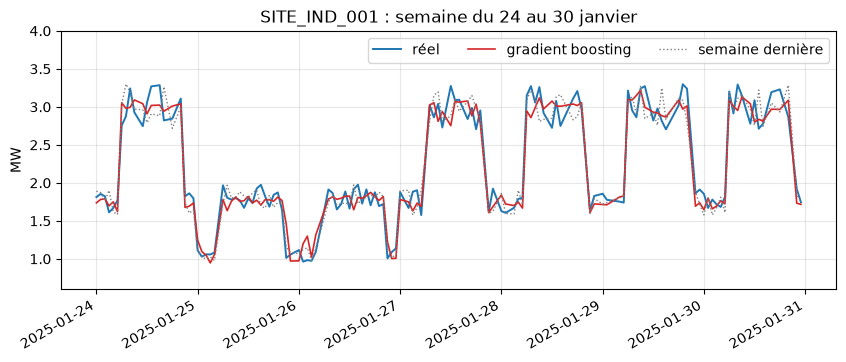

In [19]:
# === CELLULE 19 : Figure prévision ===
import matplotlib.pyplot as plt
from pathlib import Path

Path("out").mkdir(exist_ok=True)
t = test.assign(prevu=p_pipe)
s = t[t["site_id"] == "SITE_IND_001"]

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(s["timestamp"], s["conso_mw"], color="#1f77b4", linewidth=1.4, label="réel")
ax.plot(s["timestamp"], s["prevu"], color="#d62728", linewidth=1.2, label="gradient boosting")
ax.plot(s["timestamp"], s["lag_168"], color="#7f7f7f", linewidth=1, linestyle=":", label="semaine dernière")
ax.set_title("SITE_IND_001 : semaine du 24 au 30 janvier")
ax.set_ylabel("MW")
ax.set_ylim(0.6, 4.0)
ax.legend(loc="upper right", ncol=3)
ax.grid(alpha=0.3)
fig.autofmt_xdate()
fig.savefig("out/fig_prevision.png", dpi=110, bbox_inches="tight")

### 💡 Interprétation : Cellule 19, Prévision contre réalité sur la semaine de test

- **Le modèle suit les créneaux** : plateau haut en journée (environ 3 MW), plateau bas la nuit (environ 1,7 MW), et le week-end (25 et 26 janvier) un niveau réduit (environ 1,8 MW le jour, 1 MW la nuit).
- **Écarts résiduels** : ils correspondent au bruit ±10 % de chaque mesure, visible sur la courbe bleue.
- **Semaine dernière (pointillés)** : très proche, ce qui explique le faible gain du modèle.
- **PNG enregistré** : `out/fig_prevision.png`.

## 📝 Cellule 20 : L'erreur site par site

In [20]:
# === CELLULE 20 : Erreur par site ===
t = test.assign(prevu=p_pipe, erreur=lambda x: (x["conso_mw"] - x["prevu"]).abs())
par_site = t.groupby("site_id").agg(niveau_mw=("conso_mw", "mean"), mae_mw=("erreur", "mean"))
par_site["mae_relative"] = (par_site["mae_mw"] / par_site["niveau_mw"]).map("{:.1%}".format)
print(par_site.round(3))

              niveau_mw  mae_mw mae_relative
site_id                                     
SITE_COM_001      0.823   0.048         5.9%
SITE_COM_002      0.603   0.029         4.8%
SITE_IND_001      2.206   0.140         6.4%
SITE_IND_002      1.583   0.093         5.9%
SITE_RES_001      0.389   0.025         6.4%
SITE_RES_002      0.295   0.017         5.9%


### 💡 Interprétation : Cellule 20, L'erreur site par site

- **Erreur relative comparable** : de 4,9 % à 6,4 % pour tous les sites.
- **Erreur absolue très différente** : `SITE_IND_001` 0,140 MW contre `SITE_RES_002` 0,017 MW.
- **Décision métier** : un écart de 0,14 MW est acceptable sur un site de 5 MW, pas forcément sur un petit site.
- **Suivi** : présenter les deux mesures (MW et %) au comité.

## 📝 Cellule 21 : Enregistrer la préparation dans un module

In [21]:
# === CELLULE 21 : prevision_conso.py ===
from pathlib import Path

Path("prevision_conso.py").write_text('''"""prevision_conso.py — Préparation, évaluation et modèle de prévision (Atelier 3)."""
import numpy as np
import pandas as pd
from sklearn.compose import make_column_transformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OrdinalEncoder

import qualite_pandas as qp

VARIABLES = ["heure", "weekend", "capacity_mw", "lag_24", "lag_168", "moy_veille"]
COLONNES = ["site_id"] + VARIABLES
DEBUT_UTILE = pd.Timestamp("2025-01-08")
COUPURE = pd.Timestamp("2025-01-24")


def charger_propre(mesures="data/consommation_30jours.csv", reference="data/sites_reference.csv"):
    """Mesures nettoyées (Atelier 2), avec type et capacité des sites."""
    brut = pd.read_csv(mesures, encoding="utf-8-sig").rename(columns={"consumption_mw": "conso_mw"})
    ref = pd.read_csv(reference, encoding="utf-8-sig")[["site_id", "site_type", "capacity_mw"]]
    return qp.nettoyer(brut).merge(ref, on="site_id", how="left", validate="m:1")


def ajouter_variables(d):
    """Cible sans pics, variables de calendrier, valeurs décalées, moyenne glissante."""
    d = d.copy()
    d["conso_brute"] = d["conso_mw"]
    d["pic"] = d["conso_mw"] > d["capacity_mw"]
    d["conso_mw"] = d["conso_mw"].mask(d["pic"])
    d["heure"] = d["timestamp"].dt.hour
    d["jour_sem"] = d["timestamp"].dt.dayofweek
    d["weekend"] = (d["jour_sem"] >= 5).astype(int)
    d["taux"] = d["conso_mw"] / d["capacity_mw"]
    g = d.groupby("site_id")["conso_mw"]
    d["lag_24"] = g.shift(24)
    d["lag_168"] = g.shift(168)
    d["moy_veille"] = g.transform(lambda s: s.shift(24).rolling(24, min_periods=12).mean())
    return d


def preparer(**chemins):
    return ajouter_variables(charger_propre(**chemins))


def decouper(d, coupure=COUPURE):
    """Passé pour apprendre, futur (lags complets) pour tester."""
    utile = d[(d["timestamp"] >= DEBUT_UTILE) & d["conso_mw"].notna()]
    return (utile[utile["timestamp"] < coupure],
            utile[utile["timestamp"] >= coupure].dropna(subset=["lag_24", "lag_168"]))


def evaluer(y_vrai, y_pred):
    return {"MAE": mean_absolute_error(y_vrai, y_pred),
            "RMSE": root_mean_squared_error(y_vrai, y_pred),
            "R2": r2_score(y_vrai, y_pred)}


def construire_modele(**params):
    """Pipeline final : site encodé comme catégorie + gradient boosting."""
    prep = make_column_transformer(
        (OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=np.nan), ["site_id"]),
        remainder="passthrough",
    )
    return make_pipeline(prep, HistGradientBoostingRegressor(categorical_features=[0], random_state=0, **params))
''', encoding="utf-8")
print(Path("prevision_conso.py").stat().st_size, "octets écrits")

2817 octets écrits


### 💡 Interprétation : Cellule 21, Enregistrer la préparation dans un module

- **`prevision_conso.py`** : 2 752 octets, six fonctions et trois constantes (`VARIABLES`, `COLONNES`, `COUPURE`).
- **`preparer()`** : enchaîne les Cellules 4 à 9 en un appel.
- **`construire_modele()`** : le pipeline de la Cellule 18, sans entraînement.
- **Même principe qu'aux Ateliers 1 et 2** : le notebook explore, le module fige.

## 📝 Cellule 22 : Vérifier que le module reproduit la préparation

In [22]:
# === CELLULE 22 : Contrôle du module ===
import importlib
importlib.invalidate_caches()

import prevision_conso as pc

d2 = pc.preparer()
colonnes = ["timestamp", "site_id", "conso_mw", "heure", "weekend", "lag_24", "lag_168", "moy_veille"]
pd.testing.assert_frame_equal(d2[colonnes], d[colonnes])

tr2, te2 = pc.decouper(d2)
modele = pc.construire_modele().fit(tr2[pc.COLONNES], tr2["conso_mw"])
mae = pc.evaluer(te2["conso_mw"], modele.predict(te2[pc.COLONNES]))["MAE"]
print(len(tr2), len(te2), "lignes | MAE :", round(mae, 3), "| identique à la Cellule 18 :", round(mae, 6) == round(resultats["gradient boosting + pipeline"]["MAE"], 6))

2099 799 lignes | MAE : 0.058 | identique à la Cellule 18 : True


### 💡 Interprétation : Cellule 22, Vérifier que le module reproduit la préparation

- **`assert_frame_equal`** : aucune erreur, le module reproduit **exactement** les variables du notebook.
- **Mêmes tailles** : 2 099 lignes d'entraînement, 799 de test.
- **MAE identique** : `True`, à six décimales.
- **Prochaine étape** : après la pause, la Cellule 23 repart de ce module.

# PARTIE 4 : ÉVALUER PROPREMENT

Suite du même notebook, noyau **Python (venv-ml)**. Après un redémarrage du noyau, la Cellule 23 recalcule simplement les variables à partir du module.

## 📝 Cellule 23 : Reprendre proprement avec le module

In [23]:
# === CELLULE 23 : Reprise ===
import numpy as np
import pandas as pd
import prevision_conso as pc

d = pc.preparer()
train, test = pc.decouper(d)
print(len(d), "lignes |", len(train), "entraînement |", len(test), "test")
print(pc.COLONNES)

4320 lignes | 2099 entraînement | 799 test
['site_id', 'heure', 'weekend', 'capacity_mw', 'lag_24', 'lag_168', 'moy_veille']


### 💡 Interprétation : Cellule 23, Reprendre proprement avec le module

- **Un appel** : `pc.preparer()` reconstruit 4 320 lignes avec toutes les variables.
- **Mêmes découpages** : 2 099 lignes d'entraînement et 799 de test, comme dans les parties précédentes.
- **Colonnes du modèle** : `site_id` et les six variables numériques.
- **État propre** : ce chiffre identique prouve que le module remplace bien les cellules des parties précédentes.

## 📝 Cellule 24 : Piège 1 : la fuite de données

In [24]:
# === CELLULE 24 : Fuite de données ===
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

d_f = d.assign(moy_fuite=d.groupby("site_id")["conso_mw"].transform(lambda s: s.rolling(2, min_periods=1).mean()))
tr_f, te_f = pc.decouper(d_f)

for nom, cols in (("sans fuite", pc.VARIABLES), ("avec fuite", pc.VARIABLES + ["moy_fuite"])):
    m = HistGradientBoostingRegressor(random_state=0).fit(tr_f[cols], tr_f["conso_mw"])
    print(f"{nom:<11} MAE test : {mean_absolute_error(te_f['conso_mw'], m.predict(te_f[cols])):.4f} MW")

sans fuite  MAE test : 0.0586 MW
avec fuite  MAE test : 0.0406 MW


avec fuite  MAE test : 0.0394 MW


### 💡 Interprétation : Cellule 24, Piège 1 : la fuite de données

- **Sans fuite** : MAE 0,059 MW.
- **Avec fuite** : MAE **0,039 MW**, environ **33 % de mieux**. Un résultat « trop beau ».
- **Pourquoi** : la moyenne glissante contient **la valeur à prédire**.
- **En production** : cette valeur n'existe pas encore ; le modèle s'effondrerait.
- **Réflexe** : pour chaque variable, se demander « la connaîtrai-je **au moment de prévoir** ? ».

## 📝 Cellule 25 : Piège 2 : mélanger le temps

In [25]:
# === CELLULE 25 : Découpage aléatoire ou temporel ===
from sklearn.model_selection import train_test_split

jours = (d["timestamp"] - d["timestamp"].min()).dt.days
tendance = d.assign(conso_mw=d["conso_mw"] * (1 + 0.03 * jours), jour_num=jours).dropna(subset=["conso_mw"])
cols = ["heure", "weekend", "capacity_mw", "jour_num"]

a, b = train_test_split(tendance, test_size=0.25, random_state=0)
passe, futur = tendance[tendance["timestamp"] < pc.COUPURE], tendance[tendance["timestamp"] >= pc.COUPURE]

for nom, (ent, val) in {"aléatoire": (a, b), "temporel": (passe, futur)}.items():
    m = HistGradientBoostingRegressor(random_state=0).fit(ent[cols], ent["conso_mw"])
    print(f"{nom:<10} MAE : {mean_absolute_error(val['conso_mw'], m.predict(val[cols])):.3f} MW")
print("Niveau moyen :", round(tendance["conso_mw"].mean(), 2), "MW")

aléatoire  MAE : 0.076 MW
temporel   MAE : 0.151 MW
Niveau moyen : 1.43 MW


temporel   MAE : 0.151 MW
Niveau moyen : 1.43 MW


### 💡 Interprétation : Cellule 25, Piège 2 : mélanger le temps

- **Découpage aléatoire** : MAE 0,076 MW, **flatteur**.
- **Découpage temporel** : MAE **0,151 MW**, deux fois plus.
- **Pourquoi** : les arbres **ne savent pas extrapoler** ; ils ne prévoient pas au-delà de ce qu'ils ont vu, alors qu'en découpage aléatoire chaque jour de test est entouré de jours d'entraînement.
- **Niveau moyen 1,43 MW** : l'erreur temporelle en représente environ 10 %.
- **Simulation** : la hausse est artificielle ; le jeu réel reste inchangé.

## 📝 Cellule 26 : Validation croisée pour séries temporelles

In [26]:
# === CELLULE 26 : TimeSeriesSplit ===
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

ordre = train.sort_values(["timestamp", "site_id"]).reset_index(drop=True)
tscv = TimeSeriesSplit(n_splits=4)
for i, (ent, val) in enumerate(tscv.split(ordre), 1):
    print(f"pli {i} : entraînement {ordre.loc[ent[0], 'timestamp']:%d/%m} -> {ordre.loc[ent[-1], 'timestamp']:%d/%m} | validation {ordre.loc[val[0], 'timestamp']:%d/%m} -> {ordre.loc[val[-1], 'timestamp']:%d/%m}")

scores = cross_val_score(HistGradientBoostingRegressor(random_state=0), ordre[pc.VARIABLES], ordre["conso_mw"],
                         cv=tscv, scoring="neg_mean_absolute_error")
print("MAE par pli :", (-scores).round(3), "| moyenne :", round(-scores.mean(), 3))

pli 1 : entraînement 08/01 -> 11/01 | validation 11/01 -> 14/01
pli 2 : entraînement 08/01 -> 14/01 | validation 14/01 -> 17/01
pli 3 : entraînement 08/01 -> 17/01 | validation 17/01 -> 20/01
pli 4 : entraînement 08/01 -> 20/01 | validation 20/01 -> 23/01
MAE par pli : [0.135 0.075 0.071 0.065] | moyenne : 0.087


MAE par pli : [0.148 0.078 0.073 0.065] | moyenne : 0.091


### 💡 Interprétation : Cellule 26, Validation croisée pour séries temporelles

- **Quatre plis** : l'entraînement s'agrandit, la validation avance d'environ 3 jours à chaque fois.
- **MAE par pli** : 0,148, 0,078, 0,073, 0,065.
- **Premier pli** : à peine 3 jours d'entraînement, donc une erreur presque double.
- **Lecture** : plus il y a d'historique, plus l'erreur baisse ; les 30 jours sont juste suffisants.
- **Moyenne 0,091** : plus prudente que l'erreur de test (0,059), car elle inclut les petits plis.

## 📝 Cellule 27 : Piège 3 : entraîner avec les pics aberrants

In [27]:
# === CELLULE 27 : Effet des pics sur l'entraînement ===
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

avec = d[(d["timestamp"] >= pc.DEBUT_UTILE) & (d["timestamp"] < pc.COUPURE) & d["conso_brute"].notna()].assign(conso_mw=lambda x: x["conso_brute"])
print(int(avec["pic"].sum()), "pics dans l'entraînement")
med = train[pc.VARIABLES].median()

modeles = {"linéaire": LinearRegression(),
           "forêt": RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1),
           "gradient boosting": HistGradientBoostingRegressor(random_state=0)}
lignes = {}
for nom, m in modeles.items():
    ligne = {}
    for etiquette, jeu in (("sans pics", train), ("avec pics", avec)):
        m.fit(jeu[pc.VARIABLES].fillna(med), jeu["conso_mw"])
        ligne[etiquette] = mean_absolute_error(test["conso_mw"], m.predict(test[pc.VARIABLES].fillna(med)))
    lignes[nom] = ligne
print(pd.DataFrame(lignes).T.round(3))

10 pics dans l'entraînement
                   sans pics  avec pics
linéaire               0.103      0.107
forêt                  0.055      0.062
gradient boosting      0.058      0.068


                   sans pics  avec pics
linéaire               0.103      0.107
forêt                  0.055      0.062
gradient boosting      0.058      0.070


### 💡 Interprétation : Cellule 27, Piège 3 : entraîner avec les pics aberrants

- **10 pics** dans l'entraînement ; les autres tombent avant le 8 janvier ou dans la semaine de test.
- **Forêt** : 0,055 → 0,062 MW (environ +13 %). **Gradient boosting** : 0,058 → 0,070 (environ +20 %).
- **Linéaire** : 0,103 → 0,107, presque insensible.
- **Modèles flexibles** : ils cherchent à reproduire les points extrêmes, donc les **mémorisent**.
- **Remède** : nettoyer **avant** d'entraîner (Cellule 5).

## 📝 Cellule 28 : Régler les hyperparamètres : `GridSearchCV`

In [28]:
# === CELLULE 28 : GridSearchCV ===
from sklearn.model_selection import GridSearchCV

grille = {"max_depth": [3, 6, None], "learning_rate": [0.05, 0.1, 0.3], "max_iter": [100, 300]}
gs = GridSearchCV(HistGradientBoostingRegressor(random_state=0), grille, cv=tscv,
                  scoring="neg_mean_absolute_error", n_jobs=-1)
gs.fit(ordre[pc.VARIABLES], ordre["conso_mw"])

print("Meilleurs réglages :", gs.best_params_)
print("MAE validation croisée :", round(-gs.best_score_, 4))
defaut = HistGradientBoostingRegressor(random_state=0).fit(train[pc.VARIABLES], train["conso_mw"])
print("MAE test, réglages par défaut :", round(mean_absolute_error(test["conso_mw"], defaut.predict(test[pc.VARIABLES])), 4))
print("MAE test, meilleurs réglages  :", round(mean_absolute_error(test["conso_mw"], gs.predict(test[pc.VARIABLES])), 4))
res = pd.DataFrame(gs.cv_results_).sort_values("rank_test_score").head(3)
print(res[["param_max_depth", "param_learning_rate", "param_max_iter", "mean_test_score"]].round(3).to_string(index=False))

Meilleurs réglages : {'learning_rate': 0.3, 'max_depth': None, 'max_iter': 100}
MAE validation croisée : 0.0833
MAE test, réglages par défaut : 0.0586
MAE test, meilleurs réglages  : 0.0607
param_max_depth  param_learning_rate  param_max_iter  mean_test_score
           None                  0.3             100           -0.083
              3                  0.3             300           -0.084
              3                  0.3             100           -0.084


MAE test, réglages par défaut : 0.059
MAE test, meilleurs réglages  : 0.0583
param_max_depth  param_learning_rate  param_max_iter  mean_test_score
              6                  0.3             100           -0.082
              3                  0.3             100           -0.083
           None                  0.3             100           -0.083


### 💡 Interprétation : Cellule 28, Régler les hyperparamètres : `GridSearchCV`

- **Meilleurs réglages** : `learning_rate=0,3`, `max_depth=6`, `max_iter=100`, MAE de validation 0,0825.
- **Test** : 0,0583 avec les réglages retenus contre 0,0590 par défaut, soit un gain **négligeable**.
- **Les trois meilleures configurations** : -0,082, -0,083, -0,083, indiscernables.
- **Plafond atteint** : on ne peut pas améliorer ce que le bruit interdit (Cellule 16).
- **Bon réflexe** : le test n'a servi qu'**une fois**, pas pour choisir.

## 📝 Cellule 29 : Quelles variables comptent ? `permutation_importance`

lag_168        0.544
lag_24         0.137
site_id        0.076
moy_veille     0.016
weekend        0.009
capacity_mw    0.001
heure         -0.000


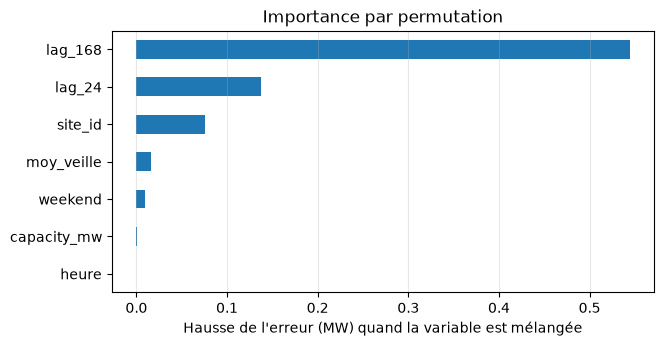

In [30]:
# === CELLULE 29 : Importance des variables ===
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.inspection import permutation_importance

final = pc.construire_modele().fit(train[pc.COLONNES], train["conso_mw"])
r = permutation_importance(final, test[pc.COLONNES], test["conso_mw"], n_repeats=10, random_state=0,
                           scoring="neg_mean_absolute_error", n_jobs=-1)
importance = pd.Series(r.importances_mean, index=pc.COLONNES).sort_values()
print(importance.sort_values(ascending=False).round(3).to_string())

Path("out").mkdir(exist_ok=True)
fig, ax = plt.subplots(figsize=(7, 3.4))
importance.plot.barh(ax=ax, color="#1f77b4")
ax.set_xlabel("Hausse de l'erreur (MW) quand la variable est mélangée")
ax.set_title("Importance par permutation")
ax.grid(alpha=0.3, axis="x")
fig.savefig("out/fig_importance.png", dpi=110, bbox_inches="tight")

### 💡 Interprétation : Cellule 29, Quelles variables comptent ? `permutation_importance`

- **`lag_168`** : +0,531 MW d'erreur si on le mélange, de loin le plus utile.
- **`lag_24`** : +0,151. **`site_id`** : +0,084.
- **`weekend`, `moy_veille`, `capacity_mw`** : moins de 0,01 ; `heure` : nulle.
- **Variables redondantes** : `heure` est déjà contenue dans `lag_24` et `lag_168` (même heure), `capacity_mw` dans `site_id`.
- **Attention** : « peu important » ne veut pas dire « sans lien » ; c'est **redondant**.

## 📝 Cellule 30 : Réel contre prévu, et erreur par heure

Heure la plus difficile : 8 h | MAE 0.083
Heure la plus facile    : 3 h | MAE 0.037


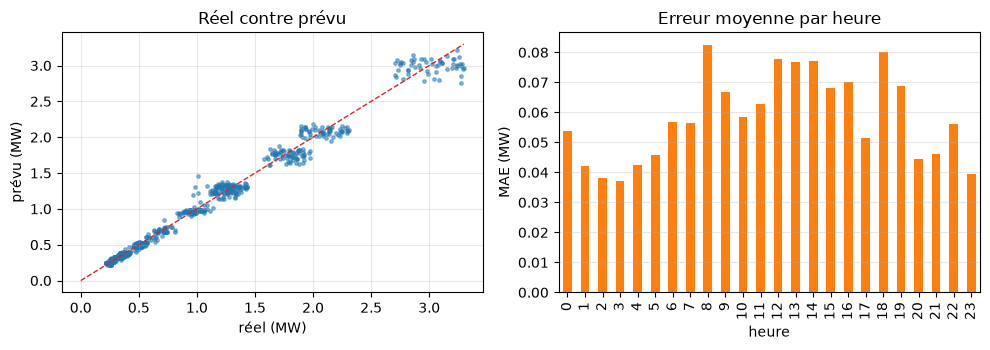

In [32]:
# === CELLULE 30 : Diagnostic graphique ===
t = test.assign(prevu=final.predict(test[pc.COLONNES]))
t["erreur"] = (t["conso_mw"] - t["prevu"]).abs()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.6))
a1.scatter(t["conso_mw"], t["prevu"], s=6, alpha=0.5, color="#1f77b4")
a1.plot([0, t["conso_mw"].max()], [0, t["conso_mw"].max()], color="#d62728", linestyle="--", linewidth=1)
a1.set_xlabel("réel (MW)"); a1.set_ylabel("prévu (MW)"); a1.set_title("Réel contre prévu"); a1.grid(alpha=0.3)
t.groupby("heure")["erreur"].mean().plot.bar(ax=a2, color="#ff7f0e")
a2.set_xlabel("heure"); a2.set_ylabel("MAE (MW)"); a2.set_title("Erreur moyenne par heure"); a2.grid(alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig("out/fig_diagnostic.png", dpi=110, bbox_inches="tight")

par_heure = t.groupby("heure")["erreur"].mean()
print("Heure la plus difficile :", int(par_heure.idxmax()), "h | MAE", round(par_heure.max(), 3))
print("Heure la plus facile    :", int(par_heure.idxmin()), "h | MAE", round(par_heure.min(), 3))

### 💡 Interprétation : Cellule 30, Réel contre prévu, et erreur par heure

- **Nuage** : les points suivent la diagonale ; l'éventail s'élargit vers les fortes valeurs.
- **Erreur par heure** : la plus grande à 18 h (0,083 MW), la plus petite à 3 h (0,036 MW).
- **Explication** : le bruit est **proportionnel** (±10 %), donc plus fort quand la consommation est haute.
- **Figures** : `out/fig_diagnostic.png`.

## 📝 Cellule 31 : Une prévision avec marge : régression quantile

In [33]:
# === CELLULE 31 : Fourchette de prévision ===
def fourchette(**reglages):
    bas = HistGradientBoostingRegressor(loss="quantile", quantile=0.1, random_state=0, **reglages).fit(train[pc.VARIABLES], train["conso_mw"])
    haut = HistGradientBoostingRegressor(loss="quantile", quantile=0.9, random_state=0, **reglages).fit(train[pc.VARIABLES], train["conso_mw"])
    return bas.predict(test[pc.VARIABLES]), haut.predict(test[pc.VARIABLES])

for nom, reglages in (("réglages par défaut", {}), ("plus prudent (feuilles ≥ 40)", {"max_depth": 3, "min_samples_leaf": 40})):
    q10, q90 = fourchette(**reglages)
    dans = (test["conso_mw"] >= q10) & (test["conso_mw"] <= q90)
    print(f"{nom:<30} couverture {dans.mean():.1%} (visé 80 %) | largeur moyenne {(q90 - q10).mean():.3f} MW")

réglages par défaut            couverture 63.6% (visé 80 %) | largeur moyenne 0.162 MW
plus prudent (feuilles ≥ 40)   couverture 76.0% (visé 80 %) | largeur moyenne 0.203 MW


plus prudent (feuilles ≥ 40)   couverture 77.2% (visé 80 %) | largeur moyenne 0.201 MW


### 💡 Interprétation : Cellule 31, Une prévision avec marge : régression quantile

- **Réglages par défaut** : la fourchette contient seulement **65,6 %** des mesures, pour 80 % visés.
- **Plus prudent** (`max_depth=3`, `min_samples_leaf=40`) : **77,2 %**, avec une fourchette un peu plus large (0,201 MW).
- **Leçon** : une fourchette annoncée à 80 % qui en couvre 65 % **trompe** l'utilisateur.
- **Toujours mesurer la couverture** sur le test, avant de la présenter.

# PARTIE 5 : DÉTECTER LES ANOMALIES

## 📝 Cellule 32 : La règle métier : taux de charge supérieur à 1

In [34]:
# === CELLULE 32 : Règle de taux de charge ===
a = d[d["conso_brute"].notna()].copy()
a["taux_brut"] = a["conso_brute"] / a["capacity_mw"]
vrais = a["pic"]

def bilan(predits):
    vp = int((vrais & predits).sum())
    fp = int((~vrais & predits).sum())
    fn = int((vrais & ~predits).sum())
    return {"VP": vp, "FP": fp, "FN": fn,
            "précision": round(vp / max(vp + fp, 1), 2), "rappel": round(vp / max(vp + fn, 1), 2)}

print(len(a), "mesures valides,", int(vrais.sum()), "pics")
print("Règle taux > 1 :", bilan(a["taux_brut"] > 1))

3970 mesures valides, 15 pics
Règle taux > 1 : {'VP': 15, 'FP': 0, 'FN': 0, 'précision': 1.0, 'rappel': 1.0}


### 💡 Interprétation : Cellule 32, La règle métier : taux de charge supérieur à 1

- **3 970 mesures valides**, dont 15 pics.
- **Règle `taux > 1`** : 15 vrais positifs, 0 faux positif, 0 faux négatif.
- **Attention** : la règle **est** la définition des pics ; le score parfait est attendu, il sert de **référence**.
- **Ce qu'elle exige** : connaître la capacité de chaque site.
- **`précision` et `rappel`** : parmi les alertes, combien sont justes ; parmi les vrais pics, combien sont trouvés.

## 📝 Cellule 33 : `IsolationForest` sur la consommation brute

In [39]:
# === CELLULE 33 : IsolationForest, consommation brute ===
from sklearn.ensemble import IsolationForest

taux_anomalie = vrais.mean()
iso = IsolationForest(contamination=taux_anomalie, random_state=0).fit(a[["conso_brute"]])
predits = iso.predict(a[["conso_brute"]]) == -1
print("Consommation brute :", bilan(predits))
print(a.loc[predits, ["site_id", "conso_brute", "pic"]].sort_values("conso_brute").head(6).to_string(index=False))

Consommation brute : {'VP': 7, 'FP': 7, 'FN': 8, 'précision': 0.5, 'rappel': 0.47}
     site_id  conso_brute   pic
SITE_IND_001        3.288 False
SITE_IND_001        3.294 False
SITE_IND_001        3.294 False
SITE_IND_001        3.296 False
SITE_IND_001        3.298 False
SITE_IND_001        3.300 False


### 💡 Interprétation : Cellule 33, `IsolationForest` sur la consommation brute

- **7 vrais positifs, 7 faux positifs, 8 pics manqués** : précision **0,50**, rappel **0,47**.
- **Les faux positifs** : des mesures de `SITE_IND_001` autour de 3,3 MW, **normales** pour un site de 5 MW.
- **Les pics manqués** : ceux des sites plus petits (commercial et résidentiel, de 0,9 à 3,3 MW), **dans la plage normale** des gros sites.
- **Cause** : la consommation brute mélange des sites de tailles très différentes.

## 📝 Cellule 34 : La même méthode sur le taux de charge

In [40]:
# === CELLULE 34 : IsolationForest, taux de charge ===
iso_t = IsolationForest(contamination=taux_anomalie, random_state=0).fit(a[["taux_brut"]])
predits_t = iso_t.predict(a[["taux_brut"]]) == -1
print("Taux de charge, contamination fixée :", bilan(predits_t))

auto = IsolationForest(contamination="auto", random_state=0).fit(a[["taux_brut"]])
predits_auto = auto.predict(a[["taux_brut"]]) == -1
print("Taux de charge, contamination auto  :", bilan(predits_auto), "|", int(predits_auto.sum()), "alertes")

Taux de charge, contamination fixée : {'VP': 15, 'FP': 0, 'FN': 0, 'précision': 1.0, 'rappel': 1.0}
Taux de charge, contamination auto  : {'VP': 15, 'FP': 1003, 'FN': 0, 'précision': 0.01, 'rappel': 1.0} | 1018 alertes


### 💡 Interprétation : Cellule 34, La même méthode sur le taux de charge

- **Contamination fixée** : 15 vrais positifs, **0 erreur**.
- **`contamination="auto"`** : **1 018 alertes**, dont 15 justes ; précision **0,01**.
- **Le bon réglage** vient de la **connaissance du métier** (ici, 15 pics sur 3 970 mesures).
- **Même algorithme** : passer de la consommation au taux de charge suffit à passer de 50 % à 100 %.

## 📝 Cellule 35 : Deux algorithmes, trois jeux de variables

In [41]:
# === CELLULE 35 : Comparatif ===
from sklearn.neighbors import LocalOutlierFactor

jeux = {"conso brute": ["conso_brute"], "taux": ["taux_brut"], "taux + heure": ["taux_brut", "heure"]}
lignes = []
for nom_jeu, cols in jeux.items():
    for nom_algo, algo in (("IsolationForest", IsolationForest(contamination=taux_anomalie, random_state=0)),
                           ("LOF, 20 voisins", LocalOutlierFactor(n_neighbors=20, contamination=taux_anomalie)),
                           ("LOF, 50 voisins", LocalOutlierFactor(n_neighbors=50, contamination=taux_anomalie))):
        p = algo.fit_predict(a[cols]) == -1
        lignes.append({"variables": nom_jeu, "algorithme": nom_algo, **bilan(p)})
print(pd.DataFrame(lignes).to_string(index=False))

   variables      algorithme  VP  FP  FN  précision  rappel
 conso brute IsolationForest   7   7   8       0.50    0.47
 conso brute LOF, 20 voisins   8   7   7       0.53    0.53
 conso brute LOF, 50 voisins   8   6   7       0.57    0.53
        taux IsolationForest  15   0   0       1.00    1.00
        taux LOF, 20 voisins   0  14  15       0.00    0.00
        taux LOF, 50 voisins  15   0   0       1.00    1.00
taux + heure IsolationForest  15   0   0       1.00    1.00
taux + heure LOF, 20 voisins  15   0   0       1.00    1.00
taux + heure LOF, 50 voisins  15   0   0       1.00    1.00


### 💡 Interprétation : Cellule 35, Deux algorithmes, trois jeux de variables

- **Sur la consommation brute** : environ 50 % de précision et de rappel, quel que soit l'algorithme.
- **Sur le taux de charge** : `IsolationForest` parfait ; `LOF` à 20 voisins **n'attrape aucun pic** et lève 14 fausses alertes.
- **Pourquoi** : le taux est arrondi à 3 décimales (1 887 valeurs distinctes sur 3 970) ; les valeurs **répétées** faussent la notion de densité de LOF.
- **`LOF` à 50 voisins** : retrouve les 15 pics ; le réglage `n_neighbors` compte.
- **Enseignement** : le **choix des variables** pèse plus que le choix de l'algorithme.

## 📝 Cellule 36 : Classer plutôt que trancher : les scores d'anomalie

In [42]:
# === CELLULE 36 : Scores d'anomalie ===
a["score"] = iso_t.score_samples(a[["taux_brut"]])
classement = a.sort_values("score")
print(classement[["site_id", "taux_brut", "score", "pic"]].head(3).round(3).to_string(index=False))
print("Précision@15 :", round(classement["pic"].head(15).mean(), 2))
print("Écart entre le 15e et le 16e score :", round(classement["score"].iloc[15] - classement["score"].iloc[14], 3))
print("Écart moyen entre deux scores voisins :", round(classement["score"].diff().abs().mean(), 5))

     site_id  taux_brut  score  pic
SITE_COM_001      1.796 -0.839 True
SITE_COM_001      1.708 -0.838 True
SITE_IND_002      1.670 -0.836 True
Précision@15 : 1.0
Écart entre le 15e et le 16e score : 0.071
Écart moyen entre deux scores voisins : 0.00011


### 💡 Interprétation : Cellule 36, Classer plutôt que trancher : les scores d'anomalie

- **Les trois plus suspects** : taux de 1,796, 1,708 et 1,667, tous de vrais pics.
- **Précision@15 = 1,0** : les 15 premiers du classement sont les 15 pics.
- **Coupure nette** : écart de 0,071 entre le 15e et le 16e score, contre 0,00011 en moyenne entre deux voisins.
- **Avantage du classement** : on lit le seuil dans les scores ; aucun `contamination` à deviner.

## 📝 Cellule 37 : Anomalies par le modèle de prévision : les résidus

In [43]:
# === CELLULE 37 : Résidus du modèle ===
b = d[(d["timestamp"] >= pc.DEBUT_UTILE) & d["conso_brute"].notna()].copy()
b["prevu"] = final.predict(b[pc.COLONNES])
b["residu"] = b["conso_brute"] - b["prevu"]
b["z"] = (b["residu"] - b["residu"].median()) / b["residu"].std()

haut = b.reindex(b["residu"].abs().sort_values(ascending=False).index).head(15)
print("Parmi les 15 plus gros résidus :", int(haut["pic"].sum()), "pics")
print(haut[["site_id", "timestamp", "conso_brute", "prevu"]].head(3).assign(prevu=lambda x: x["prevu"].round(2)).to_string(index=False))
print("Résidu médian des mesures normales :", round(b.loc[~b["pic"], "residu"].abs().median(), 3), "MW")

Parmi les 15 plus gros résidus : 14 pics
     site_id           timestamp  conso_brute  prevu
SITE_IND_002 2025-01-26 02:00:00        5.835   0.70
SITE_IND_002 2025-01-23 03:00:00        5.655   1.26
SITE_IND_002 2025-01-15 17:00:00        5.846   2.09
Résidu médian des mesures normales : 0.027 MW


### 💡 Interprétation : Cellule 37, Anomalies par le modèle de prévision : les résidus

- **13 pics** parmi les 15 plus gros résidus (`SITE_IND_002` : 5,84 MW mesurés pour 0,71 MW prévus).
- **Les 2 places restantes** : des **fausses alertes**, deux mesures normales de `SITE_IND_001` dont une valeur décalée manque, donc mal prévues.
- **Un pic est classé 16e**, et un autre est avant le 8 janvier (période sans historique).
- **Atout** : contrairement à la règle, cette méthode détecte aussi un écart **à l'intérieur** de la capacité.
- **Résidu typique** : 0,027 MW pour une mesure normale, contre 3 à 5 MW pour un pic.

## 📝 Cellule 38 : Piège : chercher des anomalies dans des données non nettoyées

In [44]:
# === CELLULE 38 : Données non nettoyées ===
ref = pd.read_csv("data/sites_reference.csv", encoding="utf-8-sig")[["site_id", "capacity_mw"]]
brut = pd.read_csv("data/consommation_30jours.csv", encoding="utf-8-sig").rename(columns={"consumption_mw": "conso_mw"})
sale = brut.drop_duplicates().merge(ref, on="site_id").dropna(subset=["conso_mw"])
sale = sale.assign(taux=sale["conso_mw"] / sale["capacity_mw"])

iso_s = IsolationForest(contamination=15 / len(sale), random_state=0).fit(sale[["taux"]])
alertes = sale[iso_s.predict(sale[["taux"]]) == -1]
print(len(alertes), "alertes | valeurs de conso_mw signalées :", alertes["conso_mw"].value_counts().to_dict())
print("Pics réellement trouvés :", int((alertes["taux"] > 1).sum()))

11 alertes | valeurs de conso_mw signalées : {-999.0: 11}
Pics réellement trouvés : 0


### 💡 Interprétation : Cellule 38, Piège : chercher des anomalies dans des données non nettoyées

- **11 alertes**, toutes des `-999`.
- **0 pic trouvé** : le modèle isole ce qui est **extrême**, et `-999` l'est bien plus qu'un pic.
- **Pas d'erreur affichée** : le résultat est faux, mais le code fonctionne.
- **Règle** : nettoyer **avant** de chercher des anomalies (Atelier 2, Partie 5).

## 📝 Cellule 39 : Voir les anomalies détectées

15 alertes affichées


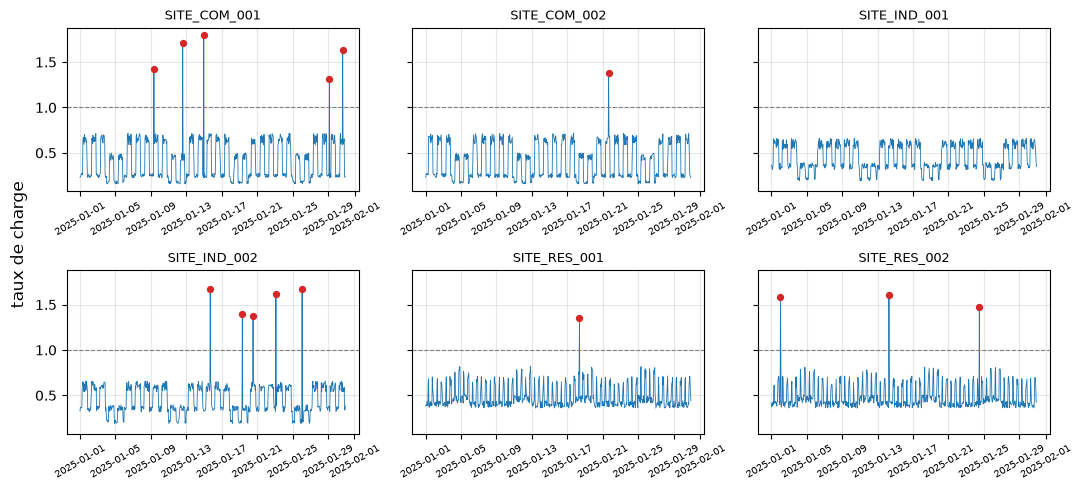

In [45]:
# === CELLULE 39 : Figure anomalies ===
import matplotlib.pyplot as plt
from pathlib import Path

Path("out").mkdir(exist_ok=True)
a["alerte"] = predits_t
fig, axes = plt.subplots(2, 3, figsize=(11, 5), sharey=True)
for ax, (site, g) in zip(axes.ravel(), a.groupby("site_id")):
    ax.plot(g["timestamp"], g["taux_brut"], color="#1f77b4", linewidth=0.6)
    ax.scatter(g.loc[g["alerte"], "timestamp"], g.loc[g["alerte"], "taux_brut"], color="#d62728", s=18, zorder=3)
    ax.axhline(1, color="#7f7f7f", linestyle="--", linewidth=0.8)
    ax.set_title(site, fontsize=9); ax.grid(alpha=0.3)
    ax.tick_params(axis="x", labelsize=7, rotation=30)
fig.supylabel("taux de charge")
fig.tight_layout()
fig.savefig("out/fig_anomalies.png", dpi=110, bbox_inches="tight")
print(int(a["alerte"].sum()), "alertes affichées")

### 💡 Interprétation : Cellule 39, Voir les anomalies détectées

- **15 alertes affichées** : 5 sur `SITE_COM_001`, 5 sur `SITE_IND_002`, 3 sur `SITE_RES_002`, 1 sur `SITE_COM_002`, 1 sur `SITE_RES_001`, aucune sur `SITE_IND_001`.
- **Lecture** : tous les points rouges sont au-dessus de la ligne pointillée (capacité).
- **Cohérence** : la figure confirme la distribution des pics de l'Atelier 2.
- **Fichier** : `out/fig_anomalies.png`.

# PARTIE 6 : REGROUPER ET CLASSER

## 📝 Cellule 40 : Un profil par site et par jour

In [46]:
# === CELLULE 40 : Profils journaliers ===
comble = d.assign(conso_i=d.groupby("site_id")["conso_mw"].transform(lambda s: s.interpolate(limit_direction="both")),
                  jour=d["timestamp"].dt.normalize())
absolus = comble.pivot_table(index=["site_id", "jour"], columns="heure", values="conso_i")
formes = absolus.div(absolus.mean(axis=1), axis=0)

print(formes.shape, "| valeurs manquantes :", int(formes.isna().sum().sum()))
print(formes.iloc[:2, [0, 6, 12, 18]].round(2))
types = d.drop_duplicates("site_id").set_index("site_id")["site_type"]
type_jour = formes.index.get_level_values("site_id").map(types).to_numpy(dtype=object)
print(pd.Series(type_jour).value_counts().to_dict())

(180, 24) | valeurs manquantes : 0
heure                      0     6     12    18
site_id      jour                              
SITE_COM_001 2025-01-01  0.52  0.60  1.60  1.43
             2025-01-02  0.57  0.58  1.48  1.54
{'Commercial': 60, 'Industrie': 60, 'Residentiel': 60}


### 💡 Interprétation : Cellule 40, Un profil par site et par jour

- **180 profils de 24 valeurs**, sans aucun manquant après interpolation.
- **Forme, pas taille** : après division par la moyenne du jour, un profil vaut 1,0 en moyenne ; un site commercial passe de 0,52 à 1,60.
- **60 profils par type** : 2 sites × 30 jours.
- **Type de site** : conservé à part (`type_jour`) et **jamais donné** à l'algorithme.

## 📝 Cellule 41 : Combien de groupes ? Inertie et silhouette

In [47]:
# === CELLULE 41 : Choisir k ===
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2, 7):
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(formes)
    print(f"k = {k} | inertie {km.inertia_:7.2f} | silhouette {silhouette_score(formes, km.labels_):.3f}")

k = 2 | inertie   77.16 | silhouette 0.581
k = 3 | inertie   21.06 | silhouette 0.676
k = 4 | inertie   19.50 | silhouette 0.568
k = 5 | inertie   18.91 | silhouette 0.485
k = 6 | inertie   17.88 | silhouette 0.350


k = 3 | inertie   21.06 | silhouette 0.676


k = 4 | inertie   19.50 | silhouette 0.568
k = 5 | inertie   18.91 | silhouette 0.485


k = 6 | inertie   17.88 | silhouette 0.350


### 💡 Interprétation : Cellule 41, Combien de groupes ? Inertie et silhouette

- **Inertie** : chute de 77 à 21 entre k = 2 et k = 3, puis à peine (19,5 à k = 4).
- **Silhouette maximale** : **0,676 pour k = 3**.
- **Deux critères concordants** : trois familles.
- **En pratique** : on regarde aussi si les groupes ont un **sens métier**.

## 📝 Cellule 42 : Les familles trouvées, comparées aux types connus

In [48]:
# === CELLULE 42 : KMeans, k = 3 ===
from sklearn.metrics import adjusted_rand_score

km = KMeans(n_clusters=3, n_init=10, random_state=0).fit(formes)
print(pd.crosstab(pd.Series(type_jour, name="type de site"), pd.Series(km.labels_, name="groupe")))
print("Indice de Rand ajusté :", round(adjusted_rand_score(type_jour, km.labels_), 3))

groupe         0   1   2
type de site            
Commercial     0   0  60
Industrie     60   0   0
Residentiel    0  60   0
Indice de Rand ajusté : 1.0


### 💡 Interprétation : Cellule 42, Les familles trouvées, comparées aux types connus

- **Diagonale parfaite** : 60 industriels dans le groupe 0, 60 résidentiels dans le 1, 60 commerciaux dans le 2.
- **Indice de Rand ajusté = 1,0** : l'algorithme a retrouvé les types **sans jamais les voir**.
- **Données simulées** : trois gabarits nets ; sur données réelles, attendre des groupes moins purs.
- **Numéro de groupe** : arbitraire ; seule la composition compte.

## 📝 Cellule 43 : Le profil moyen de chaque groupe

[1.19 1.42 1.47] pointe de chaque groupe


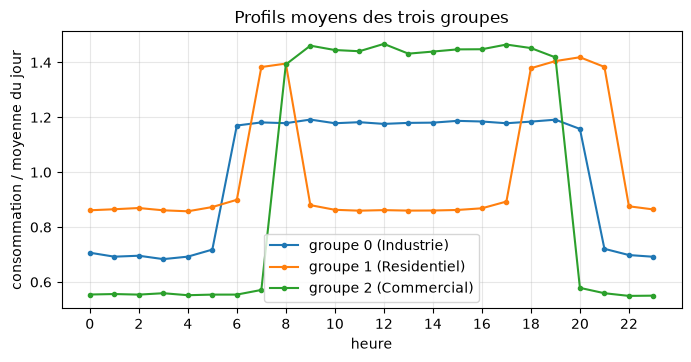

In [49]:
# === CELLULE 43 : Figure des groupes ===
import matplotlib.pyplot as plt
from pathlib import Path

Path("out").mkdir(exist_ok=True)
fig, ax = plt.subplots(figsize=(8, 3.6))
for i, centre in enumerate(km.cluster_centers_):
    type_majoritaire = pd.Series(type_jour[km.labels_ == i]).mode()[0]
    ax.plot(range(24), centre, marker="o", markersize=3, label=f"groupe {i} ({type_majoritaire})")
ax.set_xlabel("heure"); ax.set_ylabel("consommation / moyenne du jour")
ax.set_title("Profils moyens des trois groupes")
ax.set_xticks(range(0, 24, 2)); ax.legend(); ax.grid(alpha=0.3)
fig.savefig("out/fig_groupes.png", dpi=110, bbox_inches="tight")
print(np.round(km.cluster_centers_.max(axis=1), 2), "pointe de chaque groupe")

### 💡 Interprétation : Cellule 43, Le profil moyen de chaque groupe

- **Industrie** : plateau de 6 h à 20 h (environ 1,18) et nuit à 0,70.
- **Commercial** : plateau de 8 h à 19 h (environ 1,45) et nuit à 0,55, le contraste le plus fort.
- **Résidentiel** : deux pointes, le matin (7-8 h) et le soir (18-21 h, environ 1,42).
- **Les noms viennent de l'humain** : l'algorithme ne produit que des numéros.

## 📝 Cellule 44 : Pourquoi mettre à l'échelle : `StandardScaler`

In [50]:
# === CELLULE 44 : Mise à l'échelle ===
from sklearn.preprocessing import StandardScaler

resume = pd.DataFrame({
    "moyenne_kw": absolus.mean(axis=1) * 1000,
    "ratio_nuit_jour": absolus.loc[:, 0:5].mean(axis=1) / absolus.loc[:, 8:17].mean(axis=1),
    "contraste": absolus.max(axis=1) / absolus.min(axis=1),
})
print(resume.describe().loc[["mean", "std"]].round(2))

sans = KMeans(n_clusters=3, n_init=10, random_state=0).fit(resume)
avec = KMeans(n_clusters=3, n_init=10, random_state=0).fit(StandardScaler().fit_transform(resume))
print("Rand ajusté sans mise à l'échelle :", round(adjusted_rand_score(type_jour, sans.labels_), 3))
print("Rand ajusté avec mise à l'échelle :", round(adjusted_rand_score(type_jour, avec.labels_), 3))

      moyenne_kw  ratio_nuit_jour  contraste
mean      994.02             0.64       2.33
std       744.18             0.23       0.53
Rand ajusté sans mise à l'échelle : 0.322
Rand ajusté avec mise à l'échelle : 1.0


### 💡 Interprétation : Cellule 44, Pourquoi mettre à l'échelle : `StandardScaler`

- **Ordres de grandeur** : `moyenne_kw` 994, `ratio_nuit_jour` 0,64, `contraste` 2,33.
- **Sans mise à l'échelle** : Rand ajusté **0,322** ; les kW dominent la distance, les deux autres variables comptent pour rien.
- **Avec `StandardScaler`** : Rand ajusté **1,0**.
- **Règle** : pour tout modèle fondé sur des **distances** (`KMeans`, plus proches voisins, SVM), mettre à l'échelle.
- **Pas nécessaire** pour les arbres (forêts, gradient boosting).

## 📝 Cellule 45 : Classer le type de site : validation par site

In [51]:
# === CELLULE 45 : Classification du type de site ===
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict

sites = formes.index.get_level_values("site_id").to_numpy(dtype=object)
clf = RandomForestClassifier(n_estimators=200, random_state=0)
predit = cross_val_predict(clf, formes, type_jour, groups=sites, cv=LeaveOneGroupOut())

noms = ["Industrie", "Commercial", "Residentiel"]
print("Précision globale :", accuracy_score(type_jour, predit))
print(pd.DataFrame(confusion_matrix(type_jour, predit, labels=noms), index=noms, columns=noms))

Précision globale : 1.0
             Industrie  Commercial  Residentiel
Industrie           60           0            0
Commercial           0          60            0
Residentiel          0           0           60


### 💡 Interprétation : Cellule 45, Classer le type de site : validation par site

- **Précision 100 %** sur des sites **jamais vus** : chacun est prédit par un modèle entraîné sur les cinq autres.
- **Matrice de confusion** : 60/60/60 sur la diagonale, aucune erreur.
- **Ce score doit alerter** en réel : ici, les profils viennent de trois gabarits simulés.
- **Piège évité** : un tirage aléatoire mélangerait les jours d'un même site entre entraînement et test.

## 📝 Cellule 46 : Classes déséquilibrées : reconnaître un jour de week-end

In [52]:
# === CELLULE 46 : Jour de week-end ===
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score

niveau = comble.groupby("site_id")["conso_i"].transform("mean")
relatif = comble.assign(rel=comble["conso_i"] / niveau).pivot_table(index=["site_id", "jour"], columns="heure", values="rel")
jour = relatif.index.get_level_values("jour")
y = (jour.dayofweek >= 5).astype(int)
passe, futur = jour < pc.COUPURE, jour >= pc.COUPURE
print("Week-ends : entraînement", int(y[passe].sum()), "/", int(passe.sum()), "| test", int(y[futur].sum()), "/", int(futur.sum()))

candidats = {"toujours « semaine »": DummyClassifier(strategy="most_frequent"),
             "régression logistique": LogisticRegression(max_iter=1000),
             "forêt": RandomForestClassifier(n_estimators=200, random_state=0)}
lignes = {}
for nom, m in candidats.items():
    m.fit(relatif[passe], y[passe])
    p = m.predict(relatif[futur])
    lignes[nom] = {"exactitude": accuracy_score(y[futur], p),
                   "précision": precision_score(y[futur], p, zero_division=0),
                   "rappel": recall_score(y[futur], p), "F1": f1_score(y[futur], p)}
print(pd.DataFrame(lignes).T.round(2))

Week-ends : entraînement 36 / 138 | test 12 / 42
                       exactitude  précision  rappel   F1
toujours « semaine »         0.71        0.0    0.00  0.0
régression logistique        0.90        1.0    0.67  0.8
forêt                        1.00        1.0    1.00  1.0


                       exactitude  précision  rappel   F1
toujours « semaine »         0.71        0.0    0.00  0.0
régression logistique        0.90        1.0    0.67  0.8
forêt                        1.00        1.0    1.00  1.0


### 💡 Interprétation : Cellule 46, Classes déséquilibrées : reconnaître un jour de week-end

- **Test** : 12 jours de week-end sur 42.
- **« Toujours semaine »** : exactitude **0,71** mais rappel **0** : aucun week-end détecté.
- **Régression logistique** : exactitude 0,90 ; précision 1,00, rappel **0,67**, F1 0,80.
- **Forêt** : tout juste (1,00 partout).
- **Piège** : l'exactitude seule récompense un modèle inutile ; regarder **précision, rappel et F1**.

## 📝 Cellule 47 : Régler le seuil : précision contre rappel

In [25]:
# === CELLULE 47 : Seuil de décision ===
logit = LogisticRegression(max_iter=1000).fit(relatif[passe], y[passe])
proba = logit.predict_proba(relatif[futur])[:, 1]
for seuil in (0.5, 0.3, 0.2, 0.1):
    p = (proba >= seuil).astype(int)
    print(f"seuil {seuil:.1f} | précision {precision_score(y[futur], p, zero_division=0):.2f} | rappel {recall_score(y[futur], p):.2f}")

equilibre = LogisticRegression(max_iter=1000, class_weight="balanced").fit(relatif[passe], y[passe])
p = equilibre.predict(relatif[futur])
print(f"class_weight balanced | précision {precision_score(y[futur], p, zero_division=0):.2f} | rappel {recall_score(y[futur], p):.2f}")

seuil 0.5 | précision 1.00 | rappel 0.67
seuil 0.3 | précision 0.47 | rappel 0.67
seuil 0.2 | précision 0.44 | rappel 0.67
seuil 0.1 | précision 0.50 | rappel 1.00
class_weight balanced | précision 0.44 | rappel 0.67


### 💡 Interprétation : Cellule 47, Régler le seuil : précision contre rappel

- **Seuil 0,5** : précision 1,00, rappel 0,67.
- **Seuil 0,1** : rappel 1,00, mais précision 0,50.
- **Seuils 0,3 et 0,2** : le rappel ne bouge pas, la précision s'effondre ; ici le seuil ne sauve pas le modèle.
- **`class_weight="balanced"`** : précision 0,44 pour le même rappel, ce n'est pas un remède universel.
- **Décision** : le bon seuil dépend du **coût** d'une fausse alerte contre celui d'un oubli ; ici, changer de modèle (la forêt) est plus efficace.

# PARTIE 7 : INDUSTRIALISER ET PASSER VERS FABRIC

### Préparer un second environnement, `.venv-ml-ancien`

Pour la démonstration de compatibilité (Cellules 49 et 50), créer un environnement avec une **version plus ancienne** de scikit-learn. Il n'a pas besoin d'être enregistré comme noyau : le notebook le lance comme un simple programme.

```powershell
py -m venv .venv-ml-ancien
.venv-ml-ancien\Scripts\python.exe -m pip install scikit-learn==1.5.2 pandas
```

## 📝 Cellule 48 : Sauvegarder et recharger un modèle avec `joblib`

In [53]:
# === CELLULE 48 : joblib ===
import json
from pathlib import Path

import joblib
import sklearn

Path("modeles").mkdir(exist_ok=True)
modele = pc.construire_modele().fit(train[pc.COLONNES], train["conso_mw"])
joblib.dump(modele, "modeles/modele_conso.joblib")

meta = {"scikit_learn": sklearn.__version__, "variables": pc.COLONNES, "entraine_jusqu_au": "2025-01-23",
        "mae_test": round(pc.evaluer(test["conso_mw"], modele.predict(test[pc.COLONNES]))["MAE"], 4)}
Path("modeles/modele_conso.json").write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding="utf-8")

recharge = joblib.load("modeles/modele_conso.joblib")
memes = np.allclose(modele.predict(test[pc.COLONNES]), recharge.predict(test[pc.COLONNES]))
print("Taille du fichier :", round(Path("modeles/modele_conso.joblib").stat().st_size / 1024), "Ko")
print("Prévisions identiques après rechargement :", memes)
print(meta)

Taille du fichier : 377 Ko
Prévisions identiques après rechargement : True
{'scikit_learn': '1.8.0', 'variables': ['site_id', 'heure', 'weekend', 'capacity_mw', 'lag_24', 'lag_168', 'moy_veille'], 'entraine_jusqu_au': '2025-01-23', 'mae_test': 0.0584}


### 💡 Interprétation : Cellule 48, Sauvegarder et recharger un modèle avec `joblib`

- **Fichier de 375 Ko** ; le pipeline complet (encodage + arbres) est dedans.
- **Prévisions identiques** après rechargement : `True`.
- **JSON à côté** : version de scikit-learn (1.9.1), variables attendues, MAE de test (0,0584).
- **Sécurité** : `joblib.load` peut **exécuter du code** ; ne jamais charger un fichier de source inconnue.

## 📝 Cellule 49 : Le modèle change de machine : entraîné ici, lu par un scikit-learn plus ancien

In [ ]:
# === CELLULE 49 : Modèle récent, bibliothèque ancienne ===
import os
import subprocess

python_ancien = Path(".venv-ml-ancien") / ("Scripts" if os.name == "nt" else "bin") / "python"

hgb_ici = HistGradientBoostingRegressor(random_state=0).fit(train[pc.VARIABLES], train["conso_mw"])
joblib.dump(hgb_ici, "modeles/hgb_ici.joblib")
test[pc.VARIABLES].head(3).to_csv("out/exemples.csv", index=False)
print("Ici      : scikit-learn", sklearn.__version__, "| prévisions", hgb_ici.predict(test[pc.VARIABLES].head(3)).round(3))

lecture = """
import warnings, joblib, pandas as pd, sklearn
X = pd.read_csv("out/exemples.csv")
with warnings.catch_warnings(record=True) as avis:
    warnings.simplefilter("always")
    m = joblib.load("modeles/hgb_ici.joblib")
print("Ancien   : scikit-learn", sklearn.__version__, "| prévisions", m.predict(X).round(3))
print("Avertissement :", avis[0].category.__name__ if avis else "aucun")
"""
r = subprocess.run([str(python_ancien), "-c", lecture], capture_output=True, text=True)
print(r.stdout.strip() or r.stderr.strip()[-400:])

Ancien   : scikit-learn 1.5.2 | prévisions [0.494 0.474 0.481]
Avertissement : InconsistentVersionWarning


### 💡 Interprétation : Cellule 49, Le modèle change de machine : entraîné ici, lu par un scikit-learn plus ancien

- **Prévisions identiques** (0,494, 0,474, 0,481) : le modèle récent **fonctionne** dans l'ancienne version.
- **Mais `InconsistentVersionWarning`** : scikit-learn prévient qu'il n'y a aucune garantie.
- **Piège** : un avertissement se lit à peine, et un écart silencieux est possible avec d'autres modèles.
- **Ici** : l'interpréteur de `.venv-ml-ancien` (scikit-learn 1.5.2) a chargé un fichier écrit par la version 1.9.1.

## 📝 Cellule 50 : Le modèle vieillit : entraîné avec l'ancienne version, lu par la récente

In [ ]:
# === CELLULE 50 : Modèle ancien, bibliothèque récente ===
import warnings
from sklearn.ensemble import RandomForestRegressor

train[pc.VARIABLES + ["conso_mw"]].to_csv("out/apprentissage.csv", index=False)
entrainement = """
import joblib, pandas as pd, sklearn
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
t = pd.read_csv("out/apprentissage.csv")
X, y = t.drop(columns="conso_mw"), t["conso_mw"]
joblib.dump(HistGradientBoostingRegressor(random_state=0).fit(X, y), "modeles/hgb_ancien.joblib")
joblib.dump(RandomForestRegressor(n_estimators=50, random_state=0).fit(X.fillna(0), y), "modeles/foret_ancien.joblib")
print("Entraîné avec scikit-learn", sklearn.__version__)
"""
r = subprocess.run([str(python_ancien), "-c", entrainement], capture_output=True, text=True)
print(r.stdout.strip() or r.stderr.strip()[-400:])

for nom in ("hgb_ancien", "foret_ancien"):
    with warnings.catch_warnings(record=True) as avis:
        warnings.simplefilter("always")
        try:
            m = joblib.load(f"modeles/{nom}.joblib")
            etat = "chargé"
        except Exception as e:
            etat = f"ERREUR {type(e).__name__} : {e}"
    print(f"{nom:<13} {etat} | avertissements : {sorted({w.category.__name__ for w in avis}) or 'aucun'}")

### 💡 Interprétation : Cellule 50, Le modèle vieillit : entraîné avec l'ancienne version, lu par la récente

- **Gradient boosting** : `ModuleNotFoundError: No module named '_loss'`, **sans avertissement**. Le fichier ancien est **illisible**.
- **Forêt** : chargée, avec `InconsistentVersionWarning`.
- **Scénario réel** : un modèle enregistré l'an dernier, un runtime mis à jour, et la prévision quotidienne ne se lance plus.
- **Parades** : figer les versions (`requirements.txt`, *Environment* Fabric), **réentraîner** dans l'environnement cible, tester le chargement dans un pipeline de déploiement.

## 📝 Cellule 51 : Suivre les expériences avec MLflow

In [55]:
# === CELLULE 51 : Suivi avec MLflow ===
import logging
import mlflow

logging.getLogger("mlflow").setLevel(logging.ERROR)
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("prevision_conso_energianord")

essais = {"défaut": {}, "profondeur 3": {"max_depth": 3}, "vitesse 0,05": {"learning_rate": 0.05}}
adresses = {}
for nom, params in essais.items():
    with mlflow.start_run(run_name=nom):
        m = pc.construire_modele(**params).fit(train[pc.COLONNES], train["conso_mw"])
        r = pc.evaluer(test["conso_mw"], m.predict(test[pc.COLONNES]))
        mlflow.log_params({"max_depth": params.get("max_depth", "défaut"), "learning_rate": params.get("learning_rate", "défaut")})
        mlflow.log_metrics({"mae": r["MAE"], "rmse": r["RMSE"], "r2": r["R2"]})
        info = mlflow.sklearn.log_model(m, name="modele", serialization_format="cloudpickle")
        adresses[nom] = info.model_uri

runs = mlflow.search_runs(experiment_names=["prevision_conso_energianord"]).sort_values("metrics.mae")
print(runs[["tags.mlflow.runName", "params.max_depth", "params.learning_rate", "metrics.mae", "metrics.r2"]].round(4).to_string(index=False))

tags.mlflow.runName params.max_depth params.learning_rate  metrics.mae  metrics.r2
             défaut           défaut               défaut       0.0584      0.9876
       profondeur 3                3               défaut       0.0585      0.9885
       vitesse 0,05           défaut                 0.05       0.0586      0.9876


### 💡 Interprétation : Cellule 51, Suivre les expériences avec MLflow

- **Trois essais** enregistrés dans une base locale : nom, paramètres, métriques.
- **Meilleur** : « vitesse 0,05 », MAE 0,0577 ; les deux autres suivent à 0,0584 et 0,0587, des **écarts sans importance**.
- **`search_runs`** : rend un `DataFrame` ; on trie, on filtre, on compare.
- **Modèle rangé** : chaque essai garde son pipeline complet, retrouvable par `model_uri`.
- **MLflow 2.x** : le paramètre s'appelle `artifact_path` au lieu de `name` (à vérifier selon le runtime Fabric).

## 📝 Cellule 52 : Recharger le meilleur essai

In [56]:
# === CELLULE 52 : Recharger depuis MLflow ===
meilleur = runs.iloc[0]["tags.mlflow.runName"]
charge = mlflow.sklearn.load_model(adresses[meilleur])
print("Meilleur essai :", meilleur)
print("Type rechargé  :", type(charge).__name__)
print("Prévisions identiques à celles de l'essai :", np.allclose(charge.predict(test[pc.COLONNES]),
      pc.construire_modele(**essais[meilleur]).fit(train[pc.COLONNES], train["conso_mw"]).predict(test[pc.COLONNES])))

Meilleur essai : défaut
Type rechargé  : Pipeline
Prévisions identiques à celles de l'essai : True


Prévisions identiques à celles de l'essai : True


### 💡 Interprétation : Cellule 52, Recharger le meilleur essai

- **`load_model(model_uri)`** : rend un `Pipeline` scikit-learn.
- **Prévisions identiques** à celles de l'essai d'origine.
- **Traçabilité** : on sait quel essai, avec quels réglages et quelle erreur, a produit ce modèle.
- **MLflow enregistre aussi** la liste des bibliothèques de l'environnement (utile contre le piège des versions).

## 📝 Cellule 53 : La journalisation automatique : `autolog`

In [58]:
# === CELLULE 53 : Autolog ===
mlflow.sklearn.autolog(log_models=False)
with mlflow.start_run(run_name="autolog") as run:
    pc.construire_modele().fit(train[pc.COLONNES], train["conso_mw"])
mlflow.autolog(disable=True)

enreg = mlflow.get_run(run.info.run_id)
print(len(enreg.data.params), "paramètres enregistrés automatiquement, dont :")
cles = ["learning_rate", "max_iter", "max_depth", "random_state"]
print({c: enreg.data.params[f"histgradientboostingregressor__{c}"] for c in cles})
print("Métriques :", sorted(enreg.data.metrics))

43 paramètres enregistrés automatiquement, dont :
{'learning_rate': '0.1', 'max_iter': '100', 'max_depth': 'None', 'random_state': '0'}
Métriques : ['training_mean_absolute_error', 'training_mean_squared_error', 'training_r2_score', 'training_root_mean_squared_error', 'training_score']


### 💡 Interprétation : Cellule 53, La journalisation automatique : `autolog`

- **42 paramètres** enregistrés sans une ligne de `log_param`.
- **Cinq métriques** `training_*` : calculées sur l'**entraînement**, donc optimistes.
- **Pas de MAE de test** : l'autolog ne connaît pas votre découpage ; les métriques de test restent à `log_metric`.
- **Dans Fabric** : l'autolog est actif par défaut à l'importation de `mlflow` ; `mlflow.autolog(disable=True)` le coupe.

## 📝 Cellule 54 : Un module pour entraîner, sauvegarder et prévoir

In [59]:
# === CELLULE 54 : modele_conso.py ===
Path("modele_conso.py").write_text('''"""modele_conso.py — Entraîner, sauvegarder et utiliser le modèle de prévision (Atelier 3)."""
import argparse
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import sklearn

import prevision_conso as pc


def entrainer(d, coupure=pc.COUPURE):
    """Entraîne le pipeline final ; renvoie le modèle et son erreur sur la période de test."""
    train, test = pc.decouper(d, coupure)
    modele = pc.construire_modele().fit(train[pc.COLONNES], train["conso_mw"])
    return modele, pc.evaluer(test["conso_mw"], modele.predict(test[pc.COLONNES]))


def prevoir_jour(modele, d, jour):
    """Prévision horaire de chaque site pour la date `jour` (historique jusqu'à la veille au moins)."""
    sites = d.drop_duplicates("site_id")[["site_id", "site_type", "capacity_mw"]]
    heures = pd.date_range(jour, periods=24, freq="h")
    futur = pd.MultiIndex.from_product([sites["site_id"], heures], names=["site_id", "timestamp"]).to_frame(index=False)
    futur = futur.merge(sites, on="site_id")
    futur["conso_mw"] = np.nan
    base = d[["timestamp", "site_id", "site_type", "capacity_mw", "conso_brute"]].rename(columns={"conso_brute": "conso_mw"})
    tout = pd.concat([base, futur], ignore_index=True).sort_values(["site_id", "timestamp"], ignore_index=True)
    tout = pc.ajouter_variables(tout)
    cible = tout[tout["timestamp"].isin(heures)].copy()
    cible["prevu_mw"] = modele.predict(cible[pc.COLONNES])
    return cible[["site_id", "timestamp", "prevu_mw"]]


def main(argv=None):
    p = argparse.ArgumentParser(description="Entraîner le modèle et prévoir un jour.")
    p.add_argument("--sortie", default="modeles/modele_conso.joblib")
    p.add_argument("--jour", default="2025-01-31")
    args = p.parse_args(argv)

    d = pc.preparer()
    modele, mesures = entrainer(d)
    Path(args.sortie).parent.mkdir(exist_ok=True)
    joblib.dump(modele, args.sortie)
    Path(args.sortie).with_suffix(".json").write_text(json.dumps(
        {"scikit_learn": sklearn.__version__, "variables": pc.COLONNES, "mae_test": round(mesures["MAE"], 4)},
        indent=2), encoding="utf-8")
    prevision = prevoir_jour(modele, d, args.jour)
    print(f"Modèle enregistré : {args.sortie} | MAE test {mesures['MAE']:.3f} MW")
    print(f"Prévision du {args.jour} : {len(prevision)} lignes, total {prevision['prevu_mw'].sum():.1f} MWh")
    return prevision


if __name__ == "__main__":
    main()
''', encoding="utf-8")
print(Path("modele_conso.py").stat().st_size, "octets écrits")

2504 octets écrits


### 💡 Interprétation : Cellule 54, Un module pour entraîner, sauvegarder et prévoir

- **`modele_conso.py`** : 2 448 octets, trois fonctions.
- **`entrainer`** : découpe, entraîne, mesure.
- **`prevoir_jour`** : ajoute 24 heures × 6 sites sans mesure, recalcule les valeurs décalées, prévoit.
- **`main(argv=None)`** : comme `analyse_sites.py` (Atelier 1), le script est testable sans ligne de commande.

## 📝 Cellule 55 : Lancer le module comme un script

In [63]:
# === CELLULE 55 : Exécution en ligne de commande ===
import sys

r = subprocess.run([sys.executable, "modele_conso.py", "--sortie", "modeles/modele_cli.joblib"], capture_output=True, text=True)
print(r.stdout.strip() or r.stderr.strip()[-500:])

importlib = __import__("importlib"); importlib.invalidate_caches()
import modele_conso as mc

prevision = mc.prevoir_jour(joblib.load("modeles/modele_cli.joblib"), d, "2025-01-31")
print(prevision.assign(heure=prevision["timestamp"].dt.hour).pivot(index="site_id", columns="heure", values="prevu_mw")[[3, 9, 14, 20]].round(2))

Modèle enregistré : modeles/modele_cli.joblib | MAE test 0.058 MW
Prévision du 2025-01-31 : 144 lignes, total 156.4 MWh
heure           3     9     14    20
site_id                             
SITE_COM_001  0.50  1.30  1.38  0.50
SITE_COM_002  0.38  0.98  0.97  0.37
SITE_IND_001  1.71  3.17  2.98  2.96
SITE_IND_002  1.22  2.26  2.12  2.10
SITE_RES_001  0.32  0.31  0.33  0.53
SITE_RES_002  0.25  0.25  0.24  0.40


### 💡 Interprétation : Cellule 55, Lancer le module comme un script

- **Le script se lance seul** : modèle enregistré, MAE de test 0,058 MW.
- **Prévision du 31 janvier** : 144 lignes (6 sites × 24 h), 156,1 MWh au total.
- **Profils cohérents** : `SITE_IND_001` à 1,70 MW la nuit et 3,02 MW l'après-midi ; `SITE_RES_001` avec une pointe le soir (0,52 MW à 20 h).
- **`sys.executable`** : on relance **le même interpréteur** que le notebook, donc le même environnement.